<a href="https://colab.research.google.com/github/azka-niam/forkbelajar-kolab/blob/revert-3-main/Salinan_dari_Demo_ILT_5_Riding_the_wave_of_NLP_Experience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing

This tutorial demonstrates text classification on a dataset of bbc-text.


## Import TensorFlow

In [ ]:
# ─── Import Required Libraries ───────────────────────────────────────────────

import csv           # Built-in Python library to read CSV files
import tensorflow as tf  # Deep learning framework used to build and train our model
import numpy as np   # Library for numerical computations (arrays, math, etc.)

# Tokenizer  : converts words into numbers (integer indices)
# pad_sequences : makes all sequences the same length by adding zeros
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# layers  : building blocks of a neural network (Embedding, Dense, etc.)
# models  : container that stacks layers into a network (Sequential)
# optimizers : algorithms that update model weights during training (Adam, SGD, etc.)
from tensorflow.keras import layers, models, optimizers

import matplotlib.pyplot as plt  # Library for plotting graphs / charts

# Confirm TensorFlow loaded successfully and show the version
print("TensorFlow version:", tf.__version__)

# ─── Dataset Download (run once if bbc-text.csv is missing) ──────────────────
# bbc-text.csv
# %pip install gdown
# !gdown 1rX10xeI3eUJmOLsc4pOPY6AnCLO8DxNj


TensorFlow version: 2.21.0


## Prepare the dataset for training

In [ ]:
# ─── Hyperparameters (settings that control how the model learns) ─────────────

# vocab_size   : maximum number of unique words the model will remember
vocab_size = 1000

# embedding_dim : size of the vector used to represent each word numerically
#                 (higher = richer representation, but slower to train)
embedding_dim = 16

# max_length   : every article/sentence will be cut or padded to this many words
max_length = 120

# trunc_type  : if a sentence is TOO LONG, cut from the 'post' (end)
trunc_type = 'post'

# padding_type : if a sentence is TOO SHORT, add zeros at the 'post' (end)
padding_type = 'post'

# oov_tok      : token used to represent words NOT in the vocabulary
#                OOV = Out Of Vocabulary
oov_tok = "<OOV>"

# training_portion : fraction of data used for training (80% train, 20% validate)
training_portion = .8

# Print all settings so we can verify them at a glance
print("=== Model Hyperparameters ===")
print(f"  Vocabulary size  : {vocab_size}")
print(f"  Embedding dim    : {embedding_dim}")
print(f"  Max sequence len : {max_length}")
print(f"  Truncation type  : {trunc_type}")
print(f"  Padding type     : {padding_type}")
print(f"  OOV token        : {oov_tok}")
print(f"  Training portion : {training_portion * 100:.0f}%")


=== Model Hyperparameters ===
  Vocabulary size  : 1000
  Embedding dim    : 16
  Max sequence len : 120
  Truncation type  : post
  Padding type     : post
  OOV token        : <OOV>
  Training portion : 80%


In [ ]:
# ─── Load Dataset & Remove Stop Words ────────────────────────────────────────
# The BBC News dataset contains news articles labelled by category
# (e.g. sport, tech, business, politics, entertainment).
#
# Stop words are very common English words (e.g. "the", "is", "a") that
# carry little meaning and are removed to help the model focus on keywords.

sentences = []   # Will store the cleaned article texts
labels = []      # Will store the category label for each article

# List of common English stop words to remove from every article
stopwords = [ "a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as", "at", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "could", "did", "do", "does", "doing", "down", "during", "each", "few", "for", "from", "further", "had", "has", "have", "having", "he", "he'd", "he'll", "he's", "her", "here", "here's", "hers", "herself", "him", "himself", "his", "how", "how's", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "into", "is", "it", "it's", "its", "itself", "let's", "me", "more", "most", "my", "myself", "nor", "of", "on", "once", "only", "or", "other", "ought", "our", "ours", "ourselves", "out", "over", "own", "same", "she", "she'd", "she'll", "she's", "should", "so", "some", "such", "than", "that", "that's", "the", "their", "theirs", "them", "themselves", "then", "there", "there's", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "under", "until", "up", "very", "was", "we", "we'd", "we'll", "we're", "we've", "were", "what", "what's", "when", "when's", "where", "where's", "which", "while", "who", "who's", "whom", "why", "why's", "with", "would", "you", "you'd", "you'll", "you're", "you've", "your", "yours", "yourself", "yourselves" ]

# Open the CSV file and read it row by row
with open("./bbc-text.csv", 'r') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)  # Skip the header row (column names)
    for row in reader:
        labels.append(row[0])      # Column 0 = category label (e.g. "sport")
        sentence = row[1]          # Column 1 = article text
        # Remove each stop word surrounded by spaces to avoid partial matches
        for word in stopwords:
            token = " " + word + " "
            sentence = sentence.replace(token, " ")
        sentence = sentence.replace("  ", " ")  # Clean up any double spaces
        sentences.append(sentence)

# ─── Quick summary ────────────────────────────────────────────────────────────
print(f"Total articles loaded : {len(sentences)}")
print(f"Unique categories     : {set(labels)}")
print(f"\nFirst 5 article snippets (after stop-word removal):")
for i, s in enumerate(sentences[:5]):
    print(f"  [{i}] {s[:80]}...")


Total articles loaded : 2225
Unique categories     : {'tech', 'politics', 'sport', 'business', 'entertainment'}

First 5 article snippets (after stop-word removal):
  [0] tv future hands viewers home theatre systems plasma high-definition tvs digital ...
  [1] worldcom boss left books alone former worldcom boss bernie ebbers accused overse...
  [2] tigers wary farrell gamble leicester say will not rushed making bid andy farrell...
  [3] yeading face newcastle fa cup premiership side newcastle united face trip ryman ...
  [4] ocean s twelve raids box office ocean s twelve crime caper sequel starring georg...



## Data Exploration

Before building the model, let's **explore the dataset** to understand:
- How many articles exist per category (class balance)
- How long the articles are (to justify `max_length`)
- What stop-word removal actually does to the text


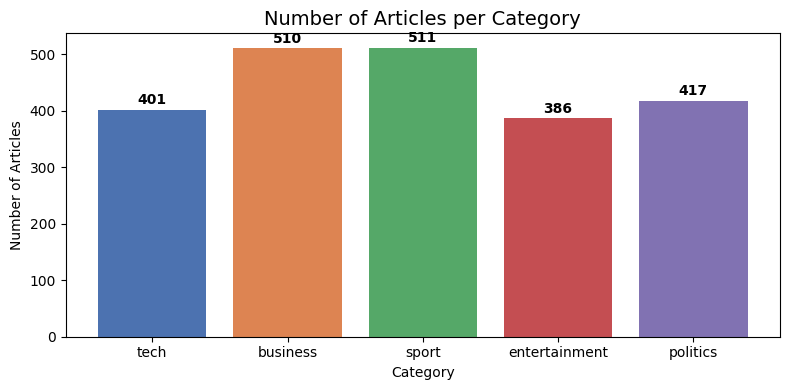

Category counts:
            sport : 511 articles
         business : 510 articles
         politics : 417 articles
             tech : 401 articles
    entertainment : 386 articles


In [ ]:

# ─── Data Exploration: Category Distribution ─────────────────────────────────
# Before training, it's important to understand how balanced the dataset is.
# If one category has far more articles than others, the model may be biased
# towards predicting that category more often.

from collections import Counter

label_counts = Counter(labels)
categories   = list(label_counts.keys())
counts       = [label_counts[c] for c in categories]

plt.figure(figsize=(8, 4))
bars = plt.bar(categories, counts,
               color=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2'])
plt.title("Number of Articles per Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Articles")
# Add count labels on top of each bar so the exact numbers are clear
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("Category counts:")
for cat, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"  {cat:>15} : {count} articles")


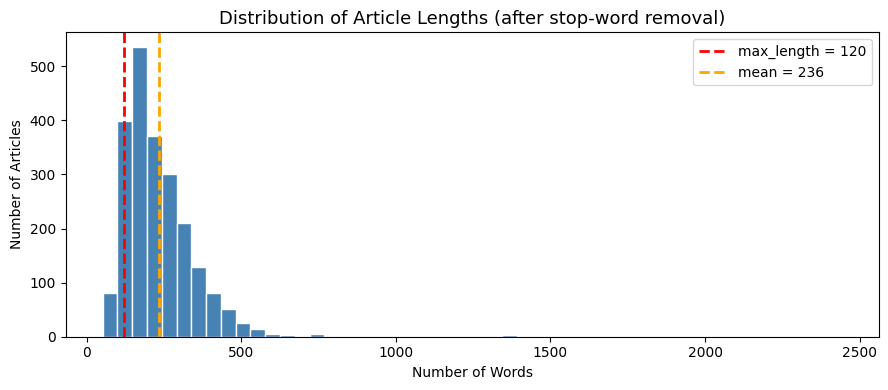

Shortest article : 52 words
Longest article  : 2442 words
Average length   : 235.6 words
Median length    : 206.0 words
Articles longer than max_length (120) → will be TRUNCATED: 90.0%


In [ ]:

# ─── Data Exploration: Article Length Distribution ────────────────────────────
# Understanding how long the articles are helps us choose a good max_length.
# If most articles are shorter than 120 words, padding covers most cases.
# If many are longer, we risk losing the tail end of articles (truncation).

word_counts = [len(s.split()) for s in sentences]

plt.figure(figsize=(9, 4))
plt.hist(word_counts, bins=50, color='steelblue', edgecolor='white')
plt.axvline(max_length, color='red', linestyle='--', linewidth=2,
            label=f'max_length = {max_length}')
plt.axvline(int(np.mean(word_counts)), color='orange', linestyle='--', linewidth=2,
            label=f'mean = {np.mean(word_counts):.0f}')
plt.title("Distribution of Article Lengths (after stop-word removal)", fontsize=13)
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.legend()
plt.tight_layout()
plt.show()

pct_truncated = sum(1 for w in word_counts if w > max_length) / len(word_counts) * 100
print(f"Shortest article : {min(word_counts)} words")
print(f"Longest article  : {max(word_counts)} words")
print(f"Average length   : {np.mean(word_counts):.1f} words")
print(f"Median length    : {np.median(word_counts):.1f} words")
print(f"Articles longer than max_length ({max_length}) → will be TRUNCATED: {pct_truncated:.1f}%")


In [ ]:

# ─── Preprocessing Insight: Before vs After Stop-Word Removal ────────────────
# Let's compare the same article before and after removing stop words.
# This makes the effect of preprocessing visible and concrete.

import csv as _csv

# Re-read the original (unprocessed) first article from the CSV
with open("./bbc-text.csv", 'r') as f:
    _reader = _csv.reader(f)
    next(_reader)          # skip header
    _first_row = next(_reader)
original_text = _first_row[1]

cleaned_text = sentences[0]   # Already cleaned version from earlier

print("─── ORIGINAL TEXT (first 200 chars) ───────────────────────────────")
print(original_text[:200])
print(f"\nWord count: {len(original_text.split())}")

print("\n─── AFTER STOP-WORD REMOVAL (first 200 chars) ─────────────────────")
print(cleaned_text[:200])
print(f"\nWord count: {len(cleaned_text.split())}")

words_removed = len(original_text.split()) - len(cleaned_text.split())
pct = words_removed / len(original_text.split()) * 100
print(f"\nWords removed: {words_removed} ({pct:.1f}% of the article)")
print("These removed words add grammar but contribute little to meaning.")


─── ORIGINAL TEXT (first 200 chars) ───────────────────────────────
tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in

Word count: 737

─── AFTER STOP-WORD REMOVAL (first 200 chars) ─────────────────────
tv future hands viewers home theatre systems plasma high-definition tvs digital video recorders moving living room way people watch tv will radically different five years time. according expert panel 

Word count: 436

Words removed: 301 (40.8% of the article)
These removed words add grammar but contribute little to meaning.


In [ ]:

# ─── Split Data into Training and Validation Sets ────────────────────────────
# We train the model on one portion of the data and test it on a separate
# portion it has never seen, to check how well it generalises.

# Calculate how many articles go into the training set (80%)
train_size = int(len(sentences) * training_portion)

# Slice the lists: first 'train_size' items → training, the rest → validation
train_sentences = sentences[:train_size]
train_labels    = labels[:train_size]

validation_sentences = sentences[train_size:]
validation_labels    = labels[train_size:]

# ─── Summary ──────────────────────────────────────────────────────────────────
print(f"Total articles        : {len(sentences)}")
print(f"Training articles     : {len(train_sentences)}  ({len(train_sentences)/len(sentences)*100:.0f}%)")
print(f"Validation articles   : {len(validation_sentences)}  ({len(validation_sentences)/len(sentences)*100:.0f}%)")

Total articles        : 2225
Training articles     : 1780  (80%)
Validation articles   : 445  (20%)


In [ ]:

# ─── Tokenisation & Padding ───────────────────────────────────────────────────
# Neural networks can't process raw text — every word must be converted into
# a number.  The Tokenizer builds a vocabulary (word → integer mapping) and
# then converts sentences into sequences of integers.

# Step 1 : Create the Tokenizer and limit the vocabulary to the top N words
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)

# Step 2 : Learn the vocabulary from the TRAINING sentences only
#           (we must NOT let the model "see" validation data during training)
tokenizer.fit_on_texts(train_sentences)

# word_index is the full dictionary: { "word": integer_id, ... }
word_index = tokenizer.word_index

# Step 3 : Convert sentences → sequences of integers
train_sequences = tokenizer.texts_to_sequences(train_sentences)
validation_sequences = tokenizer.texts_to_sequences(validation_sentences)

# Step 4 : Pad / truncate so every sequence is exactly max_length integers long
#           Shorter sentences get zeros appended; longer ones get cut.
train_padded      = pad_sequences(train_sequences,      padding=padding_type, maxlen=max_length)
validation_padded = pad_sequences(validation_sequences, padding=padding_type, maxlen=max_length)

# ─── Summary ──────────────────────────────────────────────────────────────────
print(f"Total unique words found         : {len(word_index)}")
print(f"Vocabulary size (top words kept) : {vocab_size}")
print(f"Percentage of vocabulary         : {vocab_size / len(word_index) * 100:.1f}%")
print(f"\nExample — first training sentence as integers:")
print(f"  {train_sequences[0][:15]} ...")  # Show first 15 tokens
print(f"\nShape of train_padded      : {train_padded.shape}   (articles × max_length)")
print(f"Shape of validation_padded : {validation_padded.shape}")


Total unique words found         : 27285
Vocabulary size (top words kept) : 1000
Percentage of vocabulary         : 3.7%

Example — first training sentence as integers:
  [99, 170, 1, 1, 55, 993, 771, 1, 97, 1, 1, 139, 186, 1, 1] ...

Shape of train_padded      : (1780, 120)   (articles × max_length)
Shape of validation_padded : (445, 120)


In [ ]:

# ─── Out-Of-Vocabulary (OOV) Rate ────────────────────────────────────────────
# When vocab_size is small, many words are not in the vocabulary.
# They all become token index 1 (<OOV>).
# A high OOV rate means the model is losing information — it sees the same
# "unknown" token for every word it doesn't recognise.

def oov_rate(sequences):
    """Return the percentage of tokens that are <OOV> (index 1)."""
    total_tokens = sum(len(seq) for seq in sequences)
    oov_tokens   = sum(seq.count(1) for seq in sequences)
    return oov_tokens / total_tokens * 100 if total_tokens > 0 else 0

train_oov = oov_rate(train_sequences)
val_oov   = oov_rate(validation_sequences)

print(f"OOV rate in TRAINING   data : {train_oov:.2f}%")
print(f"OOV rate in VALIDATION data : {val_oov:.2f}%")
print()
print(f"Tip: A high OOV rate (>30%) suggests vocab_size={vocab_size} may be too small.")
print(f"     Try doubling vocab_size and retraining to see if accuracy improves.")
print(f"     There is always a trade-off: larger vocab → lower OOV but more parameters.")


OOV rate in TRAINING   data : 45.12%
OOV rate in VALIDATION data : 45.39%

Tip: A high OOV rate (>30%) suggests vocab_size=1000 may be too small.
     Try doubling vocab_size and retraining to see if accuracy improves.
     There is always a trade-off: larger vocab → lower OOV but more parameters.


In [ ]:

# ─── Encode Category Labels into Numbers ─────────────────────────────────────
# The model outputs numbers, not text.  We must convert label strings like
# "sport" or "tech" into integer sequences so we can compare them to
# the model's predictions.
#
# We reuse the Tokenizer (but a fresh one) to create a simple mapping:
#   "business"      → [1]
#   "entertainment" → [2]   (exact mapping depends on frequency in the data)
#   etc.

label_tokenizer = Tokenizer()
label_tokenizer.fit_on_texts(labels)   # Learn mapping from ALL labels

# Convert label strings → integer arrays (shape: num_samples × 1)
training_label_seq   = np.array(label_tokenizer.texts_to_sequences(train_labels))
validation_label_seq = np.array(label_tokenizer.texts_to_sequences(validation_labels))

# ─── Summary ──────────────────────────────────────────────────────────────────
print("Label → Integer mapping:")
for label, idx in sorted(label_tokenizer.word_index.items(), key=lambda x: x[1]):
    print(f"  {idx}  →  {label}")

print(f"\nFirst 5 training labels (text)   : {train_labels[:5]}")
print(f"First 5 training labels (integer): {training_label_seq[:5].flatten().tolist()}")


Label → Integer mapping:
  1  →  sport
  2  →  business
  3  →  politics
  4  →  tech
  5  →  entertainment

First 5 training labels (text)   : ['tech', 'business', 'sport', 'sport', 'entertainment']
First 5 training labels (integer): [4, 2, 1, 1, 5]


## Create the model

In [ ]:

# ─── Define the Neural Network Architecture ──────────────────────────────────
# We build a simple text classifier with 4 layers:
#
#  1. Embedding   : turns word integers into dense vectors of floats
#                   (vocab_size words, each represented by embedding_dim numbers)
#  2. GlobalAveragePooling1D : averages the word vectors across the sentence,
#                              producing one fixed-size vector per article
#  3. Dense (relu)  : a fully-connected layer that learns non-linear patterns
#  4. Dense (softmax): output layer — gives a probability for each of the 6 classes

def create_model(vocab_size, embedding_dim, max_length):
    model = models.Sequential([
        # Layer 1 – Word Embedding
        layers.Embedding(vocab_size, embedding_dim, input_length=max_length),

        # Layer 2 – Pool word vectors into a single sentence vector
        layers.GlobalAveragePooling1D(),

        # Layer 3 – Hidden layer: 24 neurons, ReLU activation
        layers.Dense(24, activation='relu'),

        # Layer 4 – Output layer: 6 neurons (one per category), softmax → probabilities
        layers.Dense(6, activation='softmax')
    ])

    # Compile: choose loss function, optimiser, and metric to monitor
    # SparseCategoricalCrossentropy is used when labels are integers (not one-hot)
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=optimizers.Adam(),   # Adam adapts the learning rate automatically
        metrics=['accuracy']
    )

    return model


In [ ]:

# ─── Instantiate & Inspect the Model ─────────────────────────────────────────
# Create the model using the hyperparameters defined earlier
model = create_model(vocab_size, embedding_dim, max_length)

# model.summary() prints a table showing each layer, its output shape,
# and the number of trainable parameters (weights the model will learn)
print("Model architecture:")
model.summary()


Model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train & evaluate the model

In [ ]:

# ─── Train the Model ─────────────────────────────────────────────────────────
# model.fit() runs the training loop.
# Each pass through the full training set is called an "epoch".
#
# During training the model:
#   1. Makes predictions on training batches
#   2. Calculates the loss (how wrong it was)
#   3. Updates its weights to reduce the loss (back-propagation)
#
# validation_data lets us see how well the model does on unseen data
# after every epoch — a sanity check to spot overfitting early.

num_epochs = 30
print(f"Training for {num_epochs} epochs...")

history = model.fit(
    train_padded, training_label_seq,         # Input features & true labels
    epochs=num_epochs,
    validation_data=(validation_padded, validation_label_seq)  # Evaluate each epoch
)

# 'history' stores accuracy and loss values for every epoch — used for plotting next
print("\nTraining complete!")
print(f"Final training accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy : {history.history['val_accuracy'][-1]:.4f}")


Training for 30 epochs...
Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2826 - loss: 1.7614 - val_accuracy: 0.2787 - val_loss: 1.7056
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3253 - loss: 1.6358 - val_accuracy: 0.3753 - val_loss: 1.5649
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4331 - loss: 1.4827 - val_accuracy: 0.5236 - val_loss: 1.4158
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6208 - loss: 1.3235 - val_accuracy: 0.6562 - val_loss: 1.2565
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 1.1528 - val_accuracy: 0.8202 - val_loss: 1.0912
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8551 - loss: 0.9758 - val_accuracy: 0.8539 - val_loss: 0.9386
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8860 - loss: 0.8192 - val_accuracy: 0.8809 - val_loss: 0.8013
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9034 - loss: 0.6820 - val_ac

Accuracy over epochs:


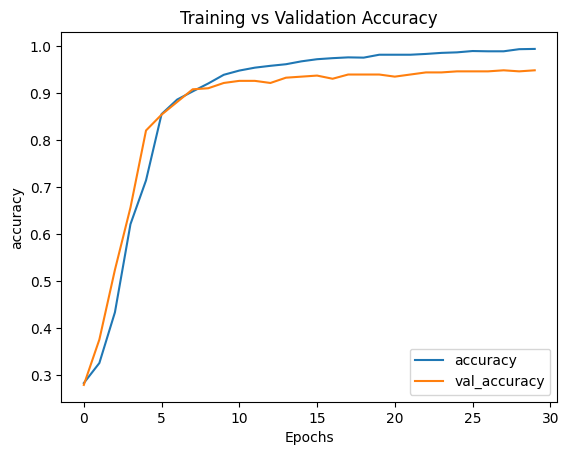

Loss over epochs:


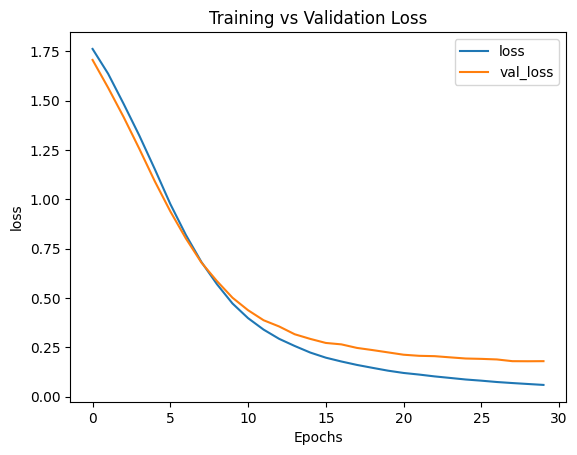

In [ ]:
# ─── Plot Training History ────────────────────────────────────────────────────
# A good training curve shows:
#   • Accuracy going UP   over epochs
#   • Loss going DOWN     over epochs
# If validation curves diverge from training curves, the model may be overfitting.

def plot_graphs(history, string):
    """Plot training vs validation metric over epochs."""
    plt.plot(history.history[string])            # Training metric
    plt.plot(history.history['val_' + string])   # Validation metric
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_' + string])
    plt.title(f"Training vs Validation {string.capitalize()}")
    plt.show()

print("Accuracy over epochs:")
plot_graphs(history, "accuracy")

print("Loss over epochs:")
plot_graphs(history, "loss")



## Model Evaluation

The training curves show us the overall trend, but they don't tell the full story.
Let's dig deeper with three additional evaluation tools:

1. **Confusion Matrix** — which categories does the model confuse with each other?
2. **Per-class Accuracy** — are some topics easier to classify than others?
3. **Misclassified Examples** — look at actual articles the model got wrong
4. **Embedding Visualisation** — has the model learned meaningful word representations?


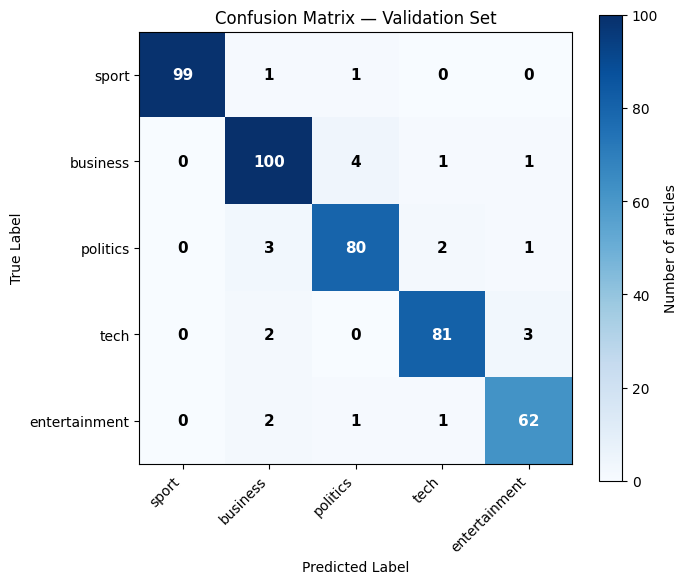

In [ ]:

# ─── Confusion Matrix ─────────────────────────────────────────────────────────
# A confusion matrix shows which categories get confused with each other.
#   • Rows  = true (actual) class
#   • Columns = predicted class
#   • The diagonal (top-left → bottom-right) = correct predictions
#   • Off-diagonal cells = mistakes (e.g. a sport article predicted as politics)

# Build index → label lookup (needed here before per-class cell runs)
_id_to_label  = {v: k for k, v in label_tokenizer.word_index.items()}
_class_names  = [_id_to_label[i] for i in range(1, len(_id_to_label) + 1)]
_n_classes    = len(_class_names)

# Get all validation predictions
_val_predictions = model.predict(validation_padded, verbose=0)
_val_pred_ids    = np.argmax(_val_predictions, axis=1)
_val_true_ids    = validation_label_seq.flatten()

# Build matrix manually (no sklearn required)
conf_matrix = np.zeros((_n_classes, _n_classes), dtype=int)
for true, pred in zip(_val_true_ids, _val_pred_ids):
    if 1 <= true <= _n_classes and 1 <= pred <= _n_classes:
        conf_matrix[int(true) - 1][int(pred) - 1] += 1

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im, ax=ax, label="Number of articles")
ax.set_xticks(range(_n_classes))
ax.set_yticks(range(_n_classes))
ax.set_xticklabels(_class_names, rotation=45, ha='right')
ax.set_yticklabels(_class_names)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix — Validation Set")

# Annotate each cell with its count
for i in range(_n_classes):
    for j in range(_n_classes):
        color = 'white' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black'
        ax.text(j, i, conf_matrix[i, j], ha='center', va='center',
                color=color, fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


In [ ]:

# ─── Per-Class Accuracy & Misclassified Examples ─────────────────────────────
# Overall accuracy can hide weaknesses.  Some categories may be easy (high
# accuracy) while others are frequently confused.

# Build index → label lookup
id_to_label  = {v: k for k, v in label_tokenizer.word_index.items()}
class_names  = [id_to_label[i] for i in range(1, len(id_to_label) + 1)]
n_classes    = len(class_names)

# Get all validation predictions at once
val_predictions = model.predict(validation_padded, verbose=0)
val_pred_ids    = np.argmax(val_predictions, axis=1)
val_true_ids    = validation_label_seq.flatten()

print("Per-class accuracy on the VALIDATION set:")
print(f"  {'Category':>15}  {'Correct':>7}  {'Total':>7}  {'Accuracy':>9}")
print("  " + "─" * 44)
for i, cname in enumerate(class_names, start=1):
    mask    = val_true_ids == i
    correct = int(np.sum(val_pred_ids[mask] == i))
    total   = int(np.sum(mask))
    acc     = correct / total * 100 if total > 0 else 0
    print(f"  {cname:>15}  {correct:>7}  {total:>7}  {acc:>8.1f}%")

# ─── 3 misclassified examples ─────────────────────────────────────────────────
print("\n─── 3 Misclassified Articles ───────────────────────────────────────────")
shown = 0
for i, (true_id, pred_id) in enumerate(zip(val_true_ids, val_pred_ids)):
    if true_id != pred_id and shown < 3:
        true_lbl = id_to_label.get(int(true_id), "?")
        pred_lbl = id_to_label.get(int(pred_id), "?")
        print(f"\n  Article [{i}]")
        print(f"    True label      : {true_lbl}")
        print(f"    Predicted label : {pred_lbl}")
        print(f"    Text snippet    : {validation_sentences[i][:130]}...")
        shown += 1


Per-class accuracy on the VALIDATION set:
         Category  Correct    Total   Accuracy
  ────────────────────────────────────────────
            sport       99      101      98.0%
         business      100      106      94.3%
         politics       80       86      93.0%
             tech       81       86      94.2%
    entertainment       62       66      93.9%

─── 3 Misclassified Articles ───────────────────────────────────────────

  Article [29]
    True label      : business
    Predicted label : politics
    Text snippet    : golden rule intact says ex-aide chancellor gordon brown will meet golden economic rule margin spare  according former chief econom...

  Article [75]
    True label      : politics
    Predicted label : tech
    Text snippet    : nuclear strike key terror risk uk us must realise cannot prevent terror attacks focus making sure not nuclear strikes says top aca...

  Article [77]
    True label      : politics
    Predicted label : business
    Text snip

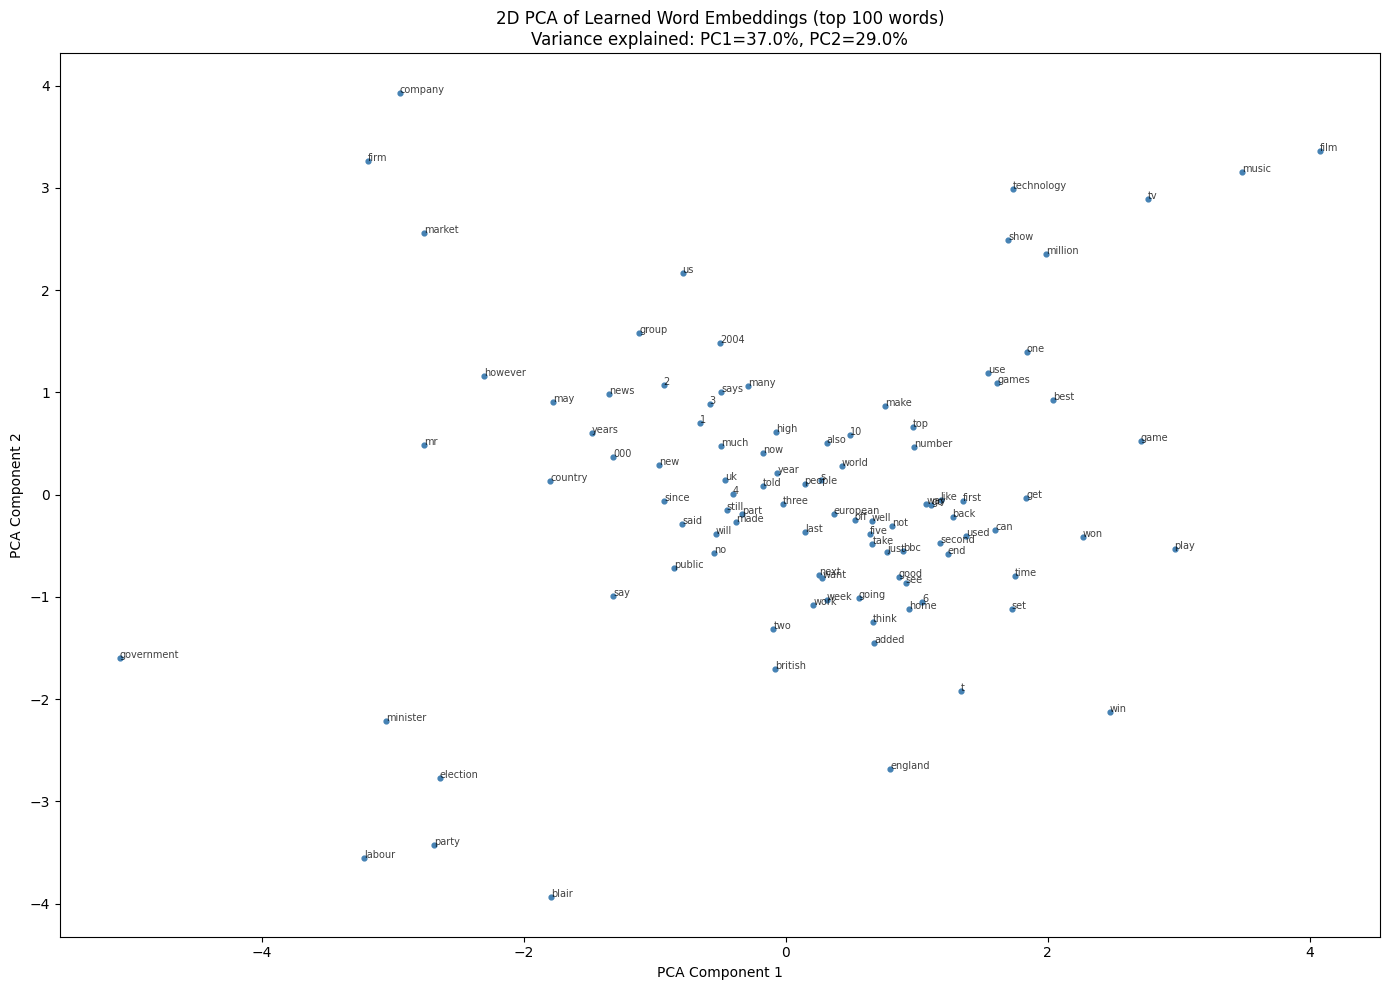

Words used in similar contexts tend to cluster together.
For example, sports words (goal, match, player) should appear near each other.


In [ ]:

# ─── Word Embedding Visualisation (PCA) ──────────────────────────────────────
# After training, the Embedding layer has learned a 16-dimensional vector
# for every word in the vocabulary.  Words used in similar contexts should
# cluster together in this space.
#
# PCA (Principal Component Analysis) collapses 16 dimensions → 2 so we can plot.

from sklearn.decomposition import PCA

# Extract learned embedding weights: shape = (vocab_size, embedding_dim)
embedding_weights = model.layers[0].get_weights()[0]

# Reduce to 2D
pca = PCA(n_components=2)
embedding_2d = pca.fit_transform(embedding_weights)

# Build the reverse lookup: integer index → word
reverse_word_index = {v: k for k, v in word_index.items()}

n_words_to_show = 100   # only show top-N most frequent words (easier to read)

plt.figure(figsize=(14, 10))
for idx in range(2, n_words_to_show + 2):   # skip 0=padding, 1=OOV
    if idx >= len(embedding_2d):
        break
    word = reverse_word_index.get(idx, "")
    x, y = embedding_2d[idx]
    plt.scatter(x, y, s=12, color='steelblue')
    plt.annotate(word, (x, y), fontsize=7, alpha=0.75)

pct_var = pca.explained_variance_ratio_ * 100
plt.title(f"2D PCA of Learned Word Embeddings (top {n_words_to_show} words)\n"
          f"Variance explained: PC1={pct_var[0]:.1f}%, PC2={pct_var[1]:.1f}%",
          fontsize=12)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

print("Words used in similar contexts tend to cluster together.")
print("For example, sports words (goal, match, player) should appear near each other.")


# Predict

In [ ]:
# ─── Inspect a Single Validation Sample ──────────────────────────────────────
# Let's manually walk through one example to understand the prediction pipeline.

# Show the raw text of the first validation article
print("First validation article (first 200 characters):")
print(validation_sentences[0][:200], "...")


First validation article (first 200 characters):
hobbit picture four years away lord rings director peter jackson said will four years starts work film version hobbit. oscar winner said visit sydney desire make not lengthy negotiations. think s gonn ...


In [ ]:

# The true category label for this article (what the correct answer should be)
print("True label (text):", validation_labels[0])


True label (text): entertainment


In [ ]:

# The same label encoded as an integer — this is what the model compares against
print("True label (integer):", validation_label_seq[0])


True label (integer): [5]


In [ ]:

# The article after tokenisation + padding — an array of 120 integers.
# Zeros at the end are the padding tokens added to reach max_length.
print(f"Padded sequence (first 30 tokens of {max_length} total):")
print(validation_padded[0][:30], "...")
print(f"\nFull shape: {validation_padded[0].shape}")


Padded sequence (first 30 tokens of 120 total):
[364   1   3  10   1 317   1   1   2 528   1  18 328  28   1   1 326   1
   1 891   1   1   1   3 301 353   1   1 508   1] ...

Full shape: (120,)


In [ ]:

# Confirm the expected integer label one more time before feeding to the model
print("Expected integer label for this sample:", validation_label_seq[0])


Expected integer label for this sample: [5]


In [ ]:

# Store the padded sequence for the first validation article in a variable
arr = validation_padded[0]
print("Padded array stored.  Shape:", arr.shape)
# Shape is (120,) — a 1D array of 120 integers


Padded array stored.  Shape: (120,)


In [ ]:

# model.predict() expects a 2D input: (batch_size, sequence_length)
# Our array is 1D (120,) so we reshape it to (1, 120) — a batch of 1 sample
reshaped_arr = arr.reshape((1, 120))
print("Reshaped array for prediction.  New shape:", reshaped_arr.shape)
# (1, 120) = 1 sample × 120 tokens


Reshaped array for prediction.  New shape: (1, 120)


In [ ]:

# Double-check the shape is correct before passing to the model
print("Input shape for model.predict():", reshaped_arr.shape)
# Expected: (1, 120)


Input shape for model.predict(): (1, 120)


In [ ]:

# Run the model on the single sample
# 'result' is a 2D array of shape (1, 6) — one probability per category
result = model.predict(reshaped_arr)

print("Raw model output (probability for each class):")
for idx, prob in enumerate(result[0]):
    label_text = label_tokenizer.sequences_to_texts([[idx]])[0] if idx > 0 else "(index 0 unused)"
    print(f"  Class {idx} {label_text:>15} : {prob:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Raw model output (probability for each class):
  Class 0 (index 0 unused) : 0.0000
  Class 1           sport : 0.0000
  Class 2        business : 0.0058
  Class 3        politics : 0.0000
  Class 4            tech : 0.0038
  Class 5   entertainment : 0.9903


In [ ]:

# np.argmax() returns the index with the HIGHEST probability — the predicted class
predicted_class_id = np.argmax(result)
predicted_label = label_tokenizer.sequences_to_texts([[predicted_class_id]])[0]

print(f"Predicted class index : {predicted_class_id}")
print(f"Predicted label       : {predicted_label}")
print(f"True label            : {validation_labels[0]}")
print(f"Correct?              : {'Yes ✓' if predicted_label == validation_labels[0] else 'No ✗'}")


Predicted class index : 5
Predicted label       : entertainment
True label            : entertainment
Correct?              : Yes ✓


# Predict from raw text

In [ ]:

# ─── Predict from Raw Text ────────────────────────────────────────────────────
# Here we test the model with a brand-new, unseen article provided as a
# plain string — exactly how you would use the model in production.

# The article is placed in a list because the tokenizer expects a list of texts
text = ["hobbit picture  four years away  lord rings director peter jackson said will four years starts work film version hobbit.  oscar winner said visit sydney  desire  make  not lengthy negotiations.  think s gonna lot lawyers sitting room trying thrash deal will ever happen   said new zealander. rights jrr tolkien s book split two major film studios. jackson  currently filming remake hollywood classic king kong  said thought sale mgm studios sony corporation cast uncertainty project. 43-year-old australian city visit lord rings exhibition  attracted 140 000 visitors since opened december.  film-maker recently sued film company new line cinema undisclosed damages alleged withheld profits lost revenue first part middle earth trilogy. fellowship ring 2001 went make worldwide profits $291 million (£152 million). jackson thought secured lucrative film directing deal history remake king kong  currently production wellington. picture  stars naomi watts oscar winner adrien brody  due released december. jackson also committed making film version lovely bones  based best-selling book alice sebold."]

print("Input text (first 200 chars):")
print(text[0][:200], "...")


Input text (first 200 chars):
hobbit picture  four years away  lord rings director peter jackson said will four years starts work film version hobbit.  oscar winner said visit sydney  desire  make  not lengthy negotiations.  think ...


In [ ]:
# ─── Inference Helper Function ────────────────────────────────────────────────
# This function takes a list of raw text strings and returns the padded
# integer sequences that the model can accept as input.

def inference(text):
    # Step 1: Convert words → integers using the same tokenizer trained earlier
    inference_sequences = tokenizer.texts_to_sequences(text)

    # Step 2: Pad / truncate to the same max_length used during training
    inference_padded = pad_sequences(inference_sequences, padding=padding_type, maxlen=max_length)

    return inference_padded


In [ ]:

# See what the text looks like after tokenisation + padding
preprocessed = inference(text)
print(f"Shape after preprocessing: {preprocessed.shape}  (1 sample × {max_length} tokens)")
print(f"First 20 token IDs: {preprocessed[0][:20]}")
# Non-zero values = recognised words; 1 = OOV token (unknown word); 0 = padding


Shape after preprocessing: (1, 120)  (1 sample × 120 tokens)
First 20 token IDs: [364   1   3  10   1 317   1   1   2 528   1  18 328  28   1   1 326   1
   1 891]


In [ ]:

# Run the model on the preprocessed text
# result shape: (1, 6) — a probability for each of the 6 categories
result = model.predict(inference(text))

print("Raw prediction probabilities (one per category):")
print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Raw prediction probabilities (one per category):
[[5.3874055e-07 4.1533531e-05 5.7696714e-03 2.0161026e-05 3.8402474e-03
  9.9032789e-01]]


In [ ]:

# ─── Decode the Prediction ────────────────────────────────────────────────────
# np.argmax finds the class index with the highest probability.
# We then convert that integer back to the human-readable category name.

pred_class_id = int(np.argmax(result, axis=1)[0])   # Integer index of the top class
pred_label    = label_tokenizer.sequences_to_texts([[pred_class_id]])[0]  # Text label

print(f"Predicted class index : {pred_class_id}")
print(f"Predicted category    : {pred_label}")
# The article is about The Hobbit / Peter Jackson — expected category: 'entertainment'


Predicted class index : 5
Predicted category    : entertainment


In [ ]:

# ─── Try It Yourself! ────────────────────────────────────────────────────────
# Change YOUR_TEXT below to any news snippet and run this cell.
# The model will predict which BBC category it belongs to.
#
# Examples to try:
#   "The stock market rose sharply today as investors reacted to earnings reports."
#   "The team scored a late winner to advance to the semi-finals."
#   "Scientists discovered a new method to improve battery efficiency in smartphones."

YOUR_TEXT = "The prime minister announced a new economic policy aimed at reducing inflation and boosting employment across the country."

# ─── (No need to change anything below this line) ────────────────────────────
_result_free = model.predict(inference([YOUR_TEXT]), verbose=0)
_pred_id     = int(np.argmax(_result_free, axis=1)[0])
_pred_label  = label_tokenizer.sequences_to_texts([[_pred_id]])[0]

print(f"Your text          : {YOUR_TEXT[:90]}...")
print(f"Predicted category : {_pred_label.upper()}")
print()
print("Confidence (probability for each category):")
for idx, prob in enumerate(_result_free[0]):
    if idx == 0:
        continue   # index 0 is unused by the tokenizer
    lbl = label_tokenizer.sequences_to_texts([[idx]])[0]
    bar = "█" * int(prob * 40)
    marker = " ← predicted" if idx == _pred_id else ""
    print(f"  {lbl:>15} : {prob:.4f}  {bar}{marker}")


Your text          : The prime minister announced a new economic policy aimed at reducing inflation and boostin...
Predicted category : SPORT

Confidence (probability for each category):
            sport : 0.7734  ██████████████████████████████ ← predicted
         business : 0.0332  █
         politics : 0.1931  ███████
             tech : 0.0000  
    entertainment : 0.0003  



# Model Comparison: ANN vs RNN vs LSTM vs GRU

So far we used a simple **ANN** (Artificial Neural Network) that treats a news article as a *bag of words* — it averages all word vectors and ignores word order.

Now let's compare it against three architectures that process text **sequentially**, reading one word at a time:

| Architecture | Key idea | Handles long-range context? | Speed |
|---|---|---|---|
| **ANN** | Average all word vectors | No | Fastest |
| **RNN** | Pass a hidden state word-by-word | Weakly | Fast |
| **LSTM** | Hidden state + memory cell + 3 gates | Yes | Slow |
| **GRU** | Simplified LSTM with 2 gates | Yes (close to LSTM) | Medium |

We will train all four for the same number of epochs and compare their validation accuracy and loss curves.


In [ ]:

# ─── Define All Four Architectures ───────────────────────────────────────────
# All models share the same Embedding layer input and Dense output,
# but differ in how they process the sequence of word vectors in between.

def build_ann(vocab_size, embedding_dim, max_length):
    """ANN — no sequence awareness; all word vectors are averaged."""
    m = models.Sequential([
        layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
        layers.GlobalAveragePooling1D(),   # Treats all word positions equally
        layers.Dense(24, activation='relu'),
        layers.Dense(6,  activation='softmax')
    ], name="ANN")
    m.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])
    return m

def build_rnn(vocab_size, embedding_dim, max_length):
    """RNN — reads words left-to-right; passes a hidden state forward."""
    m = models.Sequential([
        layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
        layers.SimpleRNN(32),              # 32 hidden units
        layers.Dense(24, activation='relu'),
        layers.Dense(6,  activation='softmax')
    ], name="RNN")
    m.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])
    return m

def build_lstm(vocab_size, embedding_dim, max_length):
    """LSTM — adds input/forget/output gates to control long-term memory."""
    m = models.Sequential([
        layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
        layers.LSTM(32),                   # 32 units; ~4× parameters of SimpleRNN
        layers.Dense(24, activation='relu'),
        layers.Dense(6,  activation='softmax')
    ], name="LSTM")
    m.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])
    return m

def build_gru(vocab_size, embedding_dim, max_length):
    """GRU — simplified LSTM with 2 gates; fewer parameters, similar accuracy."""
    m = models.Sequential([
        layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
        layers.GRU(32),                    # 32 units; ~3× parameters of SimpleRNN
        layers.Dense(24, activation='relu'),
        layers.Dense(6,  activation='softmax')
    ], name="GRU")
    m.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])
    return m

# Print parameter counts for each architecture.
# We call m.build() first because newer Keras versions require an explicit
# build step before count_params() can work on unexecuted models.
print(f"{'Model':>6}  {'Trainable parameters':>22}")
print("  " + "─" * 30)
for name, build_fn in [("ANN", build_ann), ("RNN", build_rnn),
                        ("LSTM", build_lstm), ("GRU", build_gru)]:
    m = build_fn(vocab_size, embedding_dim, max_length)
    m.build(input_shape=(None, max_length))  # Force build so count_params() works
    params = m.count_params()
    print(f"  {name:>4}  {params:>22,}")


 Model    Trainable parameters
  ──────────────────────────────
   ANN                  16,558
   RNN                  18,510
  LSTM                  23,214
   GRU                  21,742


/opt/homebrew/Caskroom/miniforge/base/envs/ml-base/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:

# ─── Train All Four Models ────────────────────────────────────────────────────
# We train each model for the SAME number of epochs so the comparison is fair.
#
# Expected training speed (slowest → fastest):
#   LSTM > GRU > RNN > ANN
# This is because recurrent models process one word at a time per step,
# while ANN averages them all simultaneously.

COMPARE_EPOCHS = 15        # Fewer epochs than before to keep runtime short
compare_histories = {}     # Store each model's history for plotting later

for name, build_fn in [("ANN",  build_ann),
                        ("RNN",  build_rnn),
                        ("LSTM", build_lstm),
                        ("GRU",  build_gru)]:
    print(f"\n{'═'*45}")
    print(f"  Training {name} for {COMPARE_EPOCHS} epochs ...")
    print(f"{'═'*45}")
    m = build_fn(vocab_size, embedding_dim, max_length)
    h = m.fit(
        train_padded, training_label_seq,
        epochs=COMPARE_EPOCHS,
        validation_data=(validation_padded, validation_label_seq),
        verbose=1
    )
    compare_histories[name] = h

print("\nAll models trained!  Scroll down to see the comparison plots.")



═════════════════════════════════════════════
  Training ANN for 15 epochs ...
═════════════════════════════════════════════
Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2702 - loss: 1.6938 - val_accuracy: 0.2270 - val_loss: 1.6225
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3360 - loss: 1.5732 - val_accuracy: 0.3236 - val_loss: 1.5353
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4708 - loss: 1.4783 - val_accuracy: 0.5978 - val_loss: 1.4259
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5921 - loss: 1.3423 - val_accuracy: 0.5371 - val_loss: 1.2851
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6461 - loss: 1.1751 - val_accuracy: 0.6292 - val_loss: 1.1244
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7719 - loss: 0.9922 - val_accuracy: 0.8180 - val_loss: 0.9537
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8449 - loss: 0.8308 - val_accuracy: 0.8539 - val_loss:

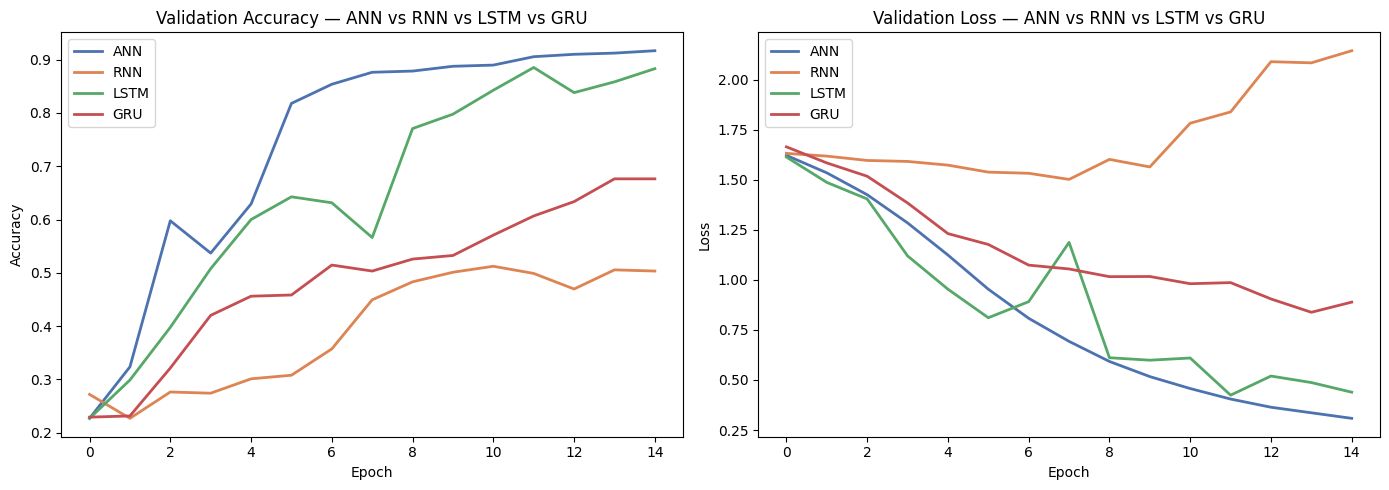

In [ ]:

# ─── Plot: Compare Validation Curves for All Four Models ─────────────────────
# Two side-by-side charts: validation accuracy (higher = better)
# and validation loss (lower = better).

colors = {"ANN": "#4C72B0", "RNN": "#DD8452", "LSTM": "#55A868", "GRU": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, h in compare_histories.items():
    axes[0].plot(h.history['val_accuracy'], label=name,
                 color=colors[name], linewidth=2)
    axes[1].plot(h.history['val_loss'],     label=name,
                 color=colors[name], linewidth=2)

axes[0].set_title("Validation Accuracy — ANN vs RNN vs LSTM vs GRU", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].set_title("Validation Loss — ANN vs RNN vs LSTM vs GRU", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:

# ─── Final Comparison Table ───────────────────────────────────────────────────
# Summarise all four models side by side.

print(f"{'Model':>6}  {'Best Val Acc':>12}  {'Final Val Acc':>13}  {'Final Val Loss':>14}")
print("  " + "─" * 50)
for name, h in compare_histories.items():
    best_acc   = max(h.history['val_accuracy'])
    final_acc  = h.history['val_accuracy'][-1]
    final_loss = h.history['val_loss'][-1]
    print(f"  {name:>4}  {best_acc:>12.4f}  {final_acc:>13.4f}  {final_loss:>14.4f}")

print()
print("Key takeaways:")
print("  ANN  : Fastest to train — ignores word ORDER (just averages all word vectors)")
print("  RNN  : Reads words left-to-right; can forget words at the start of long articles")
print("         (known as the 'vanishing gradient' problem)")
print("  LSTM : Adds 3 'gates' (input / forget / output) to control memory → better")
print("         at remembering long-range context than plain RNN")
print("  GRU  : Simplified LSTM with 2 gates — fewer parameters, similar performance,")
print("         often trains faster than LSTM")


 Model  Best Val Acc  Final Val Acc  Final Val Loss
  ──────────────────────────────────────────────────
   ANN        0.9169         0.9169          0.3084
   RNN        0.5124         0.5034          2.1456
  LSTM        0.8854         0.8831          0.4390
   GRU        0.6764         0.6764          0.8892

Key takeaways:
  ANN  : Fastest to train — ignores word ORDER (just averages all word vectors)
  RNN  : Reads words left-to-right; can forget words at the start of long articles
         (known as the 'vanishing gradient' problem)
  LSTM : Adds 3 'gates' (input / forget / output) to control memory → better
         at remembering long-range context than plain RNN
  GRU  : Simplified LSTM with 2 gates — fewer parameters, similar performance,
         often trains faster than LSTM



# Bonus: When Does Word Order Matter? — A Controlled Experiment

The BBC results showed **ANN beating LSTM/GRU**. That was *not* because LSTM is weaker
— it's because that specific task (topic classification) doesn't need word order.
The categories are identified by *which* keywords appear, not *where* they appear.

Now let's design a task where word order is the **only** signal that matters.
ANN is **mathematically guaranteed to fail** and LSTM/GRU are **guaranteed to succeed**.

---

## The Task: Ascending vs Descending Sequences

Given a sequence of 10 numbers, predict whether it is sorted **ascending** or **descending**:

| Sequence | Label |
|---|---|
| `[1, 3, 5, 7, 9, 11, 13, 15, 17, 19]` | `ascending ↑` (class 0) |
| `[19, 17, 15, 13, 11, 9, 7, 5, 3, 1]` | `descending ↓` (class 1) |

### Why ANN **must** fail here

> `GlobalAveragePooling1D` computes the **average** of all token embeddings.  
> The average of `[1,2,3,4,5]` is exactly the same as the average of `[5,4,3,2,1]`.  
> Both sequences produce **identical** input to the Dense layers → ~50% accuracy (random).

### Why LSTM / GRU will succeed

> They read the sequence **left-to-right**, one number at a time, and detect  
> whether the values are going **up** or **down** → close to 100% accuracy.

### Why RNN also works here (bonus!)

> BBC articles were 120 tokens long, which caused the vanishing gradient to kill RNN.  
> Our sequences are only **10 tokens** long — short enough that RNN's gradient  
> survives all the way back, so RNN also learns well on this task.


In [ ]:

# ─── Generate the Order-Sensitive Dataset ────────────────────────────────────
# Each sample is a sequence of 10 unique numbers drawn from 1–20.
# The label depends purely on whether the numbers are sorted ascending or descending.
#
# CRITICAL INSIGHT — run this to verify it yourself:
#   The MEAN of an ascending sequence == the MEAN of the same descending sequence.
#   So any model that only looks at averages (ANN) must score ~50% (random chance).

import random

SEQ_LENGTH  = 10    # number of tokens per sequence
SEQ_VOCAB   = 20    # pool of numbers to draw from (1 to SEQ_VOCAB)
N_TRAIN     = 3000  # training samples
N_VAL       = 750   # validation samples
EMB_DIM_SEQ = 8     # small embedding dim (vocabulary is tiny)

random.seed(42)
np.random.seed(42)

def make_order_sequences(n, seq_length=SEQ_LENGTH, vocab=SEQ_VOCAB):
    """Generate n sequences labelled by sort direction."""
    X, y = [], []
    for _ in range(n):
        nums = random.sample(range(1, vocab + 1), seq_length)
        if random.random() > 0.5:
            X.append(sorted(nums))                 # ascending  → label 0
            y.append(0)
        else:
            X.append(sorted(nums, reverse=True))   # descending → label 1
            y.append(1)
    return np.array(X), np.array(y)

seq_train_X, seq_train_y = make_order_sequences(N_TRAIN)
seq_val_X,   seq_val_y   = make_order_sequences(N_VAL)

print(f"Training set   : {seq_train_X.shape}  labels: {seq_train_y.shape}")
print(f"Validation set : {seq_val_X.shape}    labels: {seq_val_y.shape}")
print()
print("First 4 examples:")
for i in range(4):
    direction = "ascending  ↑  (label=0)" if seq_train_y[i] == 0 else "descending ↓  (label=1)"
    print(f"  {list(seq_train_X[i])}  →  {direction}")

# Prove that ANN (which averages) cannot distinguish the two classes
asc_means  = np.mean(seq_train_X[seq_train_y == 0], axis=1)
desc_means = np.mean(seq_train_X[seq_train_y == 1], axis=1)
print(f"\n  Mean token value — ascending  sequences : {asc_means.mean():.3f}")
print(f"  Mean token value — descending sequences : {desc_means.mean():.3f}")
print("\n  ⇒ Almost identical! ANN's GlobalAveragePooling sees the same representation")
print("    for both classes, making it impossible to distinguish them.")


Training set   : (3000, 10)  labels: (3000,)
Validation set : (750, 10)    labels: (750,)

First 4 examples:
  [np.int64(18), np.int64(17), np.int64(12), np.int64(11), np.int64(9), np.int64(8), np.int64(4), np.int64(3), np.int64(2), np.int64(1)]  →  descending ↓  (label=1)
  [np.int64(20), np.int64(18), np.int64(14), np.int64(10), np.int64(9), np.int64(7), np.int64(4), np.int64(3), np.int64(2), np.int64(1)]  →  descending ↓  (label=1)
  [np.int64(19), np.int64(18), np.int64(15), np.int64(14), np.int64(13), np.int64(9), np.int64(8), np.int64(7), np.int64(3), np.int64(1)]  →  descending ↓  (label=1)
  [np.int64(19), np.int64(13), np.int64(11), np.int64(10), np.int64(7), np.int64(6), np.int64(5), np.int64(4), np.int64(3), np.int64(2)]  →  descending ↓  (label=1)

  Mean token value — ascending  sequences : 10.510
  Mean token value — descending sequences : 10.463

  ⇒ Almost identical! ANN's GlobalAveragePooling sees the same representation
    for both classes, making it impossible to di

In [ ]:

# ─── Train All Four Models on the Order-Sensitive Task ───────────────────────
# We use a small embedding (EMB_DIM_SEQ=8) since the vocabulary is tiny (20 numbers).
# Binary classification: 1 output neuron with sigmoid activation.
# Loss: binary_crossentropy (standard for 2-class problems).

SEQ_VOCAB_SIZE = SEQ_VOCAB + 1   # token IDs are 1..SEQ_VOCAB; +1 for index 0

def build_seq_ann():
    """ANN — averages all position embeddings (order-blind)."""
    m = models.Sequential([
        layers.Embedding(SEQ_VOCAB_SIZE, EMB_DIM_SEQ, input_length=SEQ_LENGTH),
        layers.GlobalAveragePooling1D(),   # <- THIS is why ANN fails: averages destroy order
        layers.Dense(16, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ], name="ANN_seq")
    m.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return m

def build_seq_rnn():
    """RNN — reads left-to-right; short sequences (10 tokens) avoid vanishing gradient."""
    m = models.Sequential([
        layers.Embedding(SEQ_VOCAB_SIZE, EMB_DIM_SEQ, input_length=SEQ_LENGTH),
        layers.SimpleRNN(16),
        layers.Dense(16, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ], name="RNN_seq")
    m.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return m

def build_seq_lstm():
    """LSTM — memory gates let it reliably track whether numbers go up or down."""
    m = models.Sequential([
        layers.Embedding(SEQ_VOCAB_SIZE, EMB_DIM_SEQ, input_length=SEQ_LENGTH),
        layers.LSTM(16),
        layers.Dense(16, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ], name="LSTM_seq")
    m.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return m

def build_seq_gru():
    """GRU — similar to LSTM but with fewer parameters; also handles order well."""
    m = models.Sequential([
        layers.Embedding(SEQ_VOCAB_SIZE, EMB_DIM_SEQ, input_length=SEQ_LENGTH),
        layers.GRU(16),
        layers.Dense(16, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ], name="GRU_seq")
    m.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return m

SEQ_EPOCHS = 20
seq_histories = {}

for name, build_fn in [("ANN",  build_seq_ann),
                        ("RNN",  build_seq_rnn),
                        ("LSTM", build_seq_lstm),
                        ("GRU",  build_seq_gru)]:
    print(f"Training {name}...", end=" ", flush=True)
    m = build_fn()
    h = m.fit(
        seq_train_X, seq_train_y,
        epochs=SEQ_EPOCHS,
        validation_data=(seq_val_X, seq_val_y),
        verbose=0   # silent — we only show final result
    )
    seq_histories[name] = h
    print(f"Val accuracy = {h.history['val_accuracy'][-1]:.4f}")

print("\nAll models trained!  See the plot below.")


Training ANN... Val accuracy = 0.4893
Training RNN... Val accuracy = 1.0000
Training LSTM... Val accuracy = 1.0000
Training GRU... Val accuracy = 1.0000

All models trained!  See the plot below.


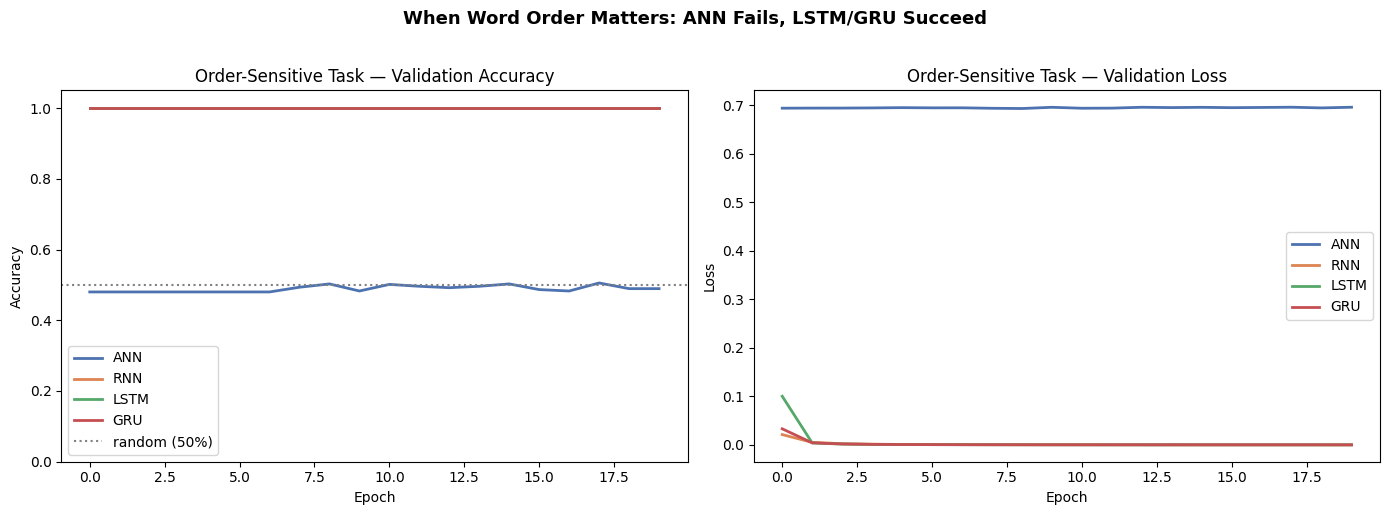

 Model  Best Val Acc  Final Val Acc  Note
  ─────────────────────────────────────────────────────────────────
   ANN        0.5053         0.4893  <── ~50% random!  ANN cannot see order
   RNN        1.0000         1.0000  
  LSTM        1.0000         1.0000  
   GRU        1.0000         1.0000  


In [ ]:

# ─── Plot & Compare: Order-Sensitive Task Results ────────────────────────────
# Expected outcome:
#   ANN  → stuck near 50% (random chance) — it can't see word order
#   RNN  → learns well since sequences are short (10 tokens, no vanishing gradient issue)
#   LSTM → learns well, close to 100%
#   GRU  → learns well, close to 100%

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"ANN": "#4C72B0", "RNN": "#DD8452", "LSTM": "#55A868", "GRU": "#C44E52"}

for name, h in seq_histories.items():
    axes[0].plot(h.history['val_accuracy'], label=name,
                 color=colors[name], linewidth=2)
    axes[1].plot(h.history['val_loss'],     label=name,
                 color=colors[name], linewidth=2)

# Dashed line at 50% = random-guess baseline for a 2-class problem
axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='random (50%)')
axes[0].set_title("Order-Sensitive Task — Validation Accuracy", fontsize=12)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].set_ylim(0, 1.05)

axes[1].set_title("Order-Sensitive Task — Validation Loss", fontsize=12)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("When Word Order Matters: ANN Fails, LSTM/GRU Succeed",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Summary table ────────────────────────────────────────────────────────────
print(f"{'Model':>6}  {'Best Val Acc':>12}  {'Final Val Acc':>13}  Note")
print("  " + "─" * 65)
for name, h in seq_histories.items():
    best  = max(h.history['val_accuracy'])
    final = h.history['val_accuracy'][-1]
    note  = "<── ~50% random!  ANN cannot see order" if name == "ANN" else ""
    print(f"  {name:>4}  {best:>12.4f}  {final:>13.4f}  {note}")



## Summary: Choosing the Right Architecture

| | ANN (bag-of-words) | RNN | LSTM / GRU |
|---|---|---|---|
| Reads word order? | No | Yes (weakly) | Yes |
| Handles long-range context? | No | Poorly | Yes |
| Speed | Fastest | Fast | Slower |
| BBC topic classification | ✅ Best | ❌ Slow to converge | 🟡 Good |
| Order-sensitive classification | ❌ ~50% (random) | 🟡 Good | ✅ Best |

**Rule of thumb:**
- Use **ANN / bag-of-words** when the *presence* of keywords matters most (topic classification, spam filtering)
- Use **LSTM / GRU** when *word order or context* matters (sentiment with negation, machine translation, text generation, NER)
- In modern NLP, **Transformers** (e.g., BERT, GPT) have largely replaced LSTM/GRU — they handle long-range context even better and train in parallel using attention mechanisms
